# Problema 1: Segmentación de Estudiantes Universitarios

## Paso 1: Comprensión del Problema

### Contexto del Problema
La coordinación académica de una universidad desea identificar perfiles de estudiantes según hábitos de estudio, rendimiento académico, niveles de estrés y comportamiento en plataformas virtuales.

### Objetivo del Análisis
Descubrir grupos ocultos de estudiantes para diseñar estrategias de acompañamiento académico.

### Tipo de Aprendizaje
- **Aprendizaje No Supervisado**: No hay etiquetas predefinidas. El SOM descubrirá patrones y agrupamientos automáticamente.

### Variables Relevantes
- **Rendimiento académico**: promedio_academico, rendimiento_programacion, tareas_entregadas
- **Hábitos de estudio**: horas_estudio_semana, asistencia_clases
- **Comportamiento virtual**: uso_plataforma_virtual, participacion_foro
- **Factores externos**: nivel_estres, horas_trabajo, acceso_internet

### ¿Por qué SOM?
- Permite descubrir patrones ocultos sin etiquetas previas
- Conserva relaciones topológicas (estudiantes similares estarán cerca en el mapa)
- Reducción de dimensionalidad: 12 variables → mapa 2D visualizable
- Identifica clusters naturales de estudiantes con perfiles similares
- Útil para segmentación y descubrimiento de perfiles estudiantiles

## Paso 2: Carga del Dataset

In [95]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
np.set_printoptions(precision=4, suppress=True)

In [96]:
with open('../jsons/dataset_som_1.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("=== INFORMACIÓN DEL DATASET ===")
print(f"\nDimensiones: {df.shape}")
print(f"  - Número de patrones (estudiantes): {df.shape[0]}")
print(f"  - Número de variables: {df.shape[1]}")

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== PRIMERAS 10 FILAS ===")
print(df.head(10))

=== INFORMACIÓN DEL DATASET ===

Dimensiones: (1200, 12)
  - Número de patrones (estudiantes): 1200
  - Número de variables: 12

=== TIPOS DE DATOS ===
edad                               int64
promedio_academico               float64
horas_estudio_semana               int64
asistencia_clases                  int64
uso_plataforma_virtual             int64
participacion_foro                 int64
tareas_entregadas                  int64
nivel_estres                       int64
acceso_internet                    int64
actividades_extracurriculares      int64
horas_trabajo                      int64
rendimiento_programacion         float64
dtype: object

=== PRIMERAS 10 FILAS ===
   edad  promedio_academico  horas_estudio_semana  asistencia_clases  \
0    20                4.60                    17                 90   
1    24                4.38                    17                 68   
2    17                3.30                     8                 50   
3    26                3.66

In [97]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

=== ESTADÍSTICAS DESCRIPTIVAS ===
              edad  promedio_academico  horas_estudio_semana  \
count  1200.000000         1200.000000           1200.000000   
mean     23.503333            4.207967             15.563333   
std       3.997287            0.701033              8.252944   
min      17.000000            2.700000              2.000000   
25%      20.000000            3.590000              9.000000   
50%      23.000000            4.330000             15.000000   
75%      27.000000            5.000000             23.000000   
max      30.000000            5.000000             30.000000   

       asistencia_clases  uso_plataforma_virtual  participacion_foro  \
count        1200.000000             1200.000000         1200.000000   
mean           75.056667               13.035833           10.058333   
std            14.818224                6.965269            5.965981   
min            50.000000                2.000000            0.000000   
25%            62.000000     

## Paso 3: Análisis Exploratorio de Datos (EDA)

In [98]:
print("=== VERIFICACIÓN DE VALORES NULOS ===")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

=== VERIFICACIÓN DE VALORES NULOS ===
edad                             0
promedio_academico               0
horas_estudio_semana             0
asistencia_clases                0
uso_plataforma_virtual           0
participacion_foro               0
tareas_entregadas                0
nivel_estres                     0
acceso_internet                  0
actividades_extracurriculares    0
horas_trabajo                    0
rendimiento_programacion         0
dtype: int64

Total de valores nulos: 0


=== MATRIZ DE CORRELACIÓN ===
                                   edad  promedio_academico  \
edad                           1.000000            0.009006   
promedio_academico             0.009006            1.000000   
horas_estudio_semana           0.013747            0.963752   
asistencia_clases             -0.035711            0.118250   
uso_plataforma_virtual         0.005373           -0.047049   
participacion_foro             0.019122           -0.025501   
tareas_entregadas              0.014884           -0.032726   
nivel_estres                   0.033596           -0.009664   
acceso_internet                0.005179            0.023320   
actividades_extracurriculares -0.024574            0.021003   
horas_trabajo                 -0.008245            0.015540   
rendimiento_programacion       0.026798           -0.031463   

                               horas_estudio_semana  asistencia_clases  \
edad                                       0.013747          -0.035711   
pr

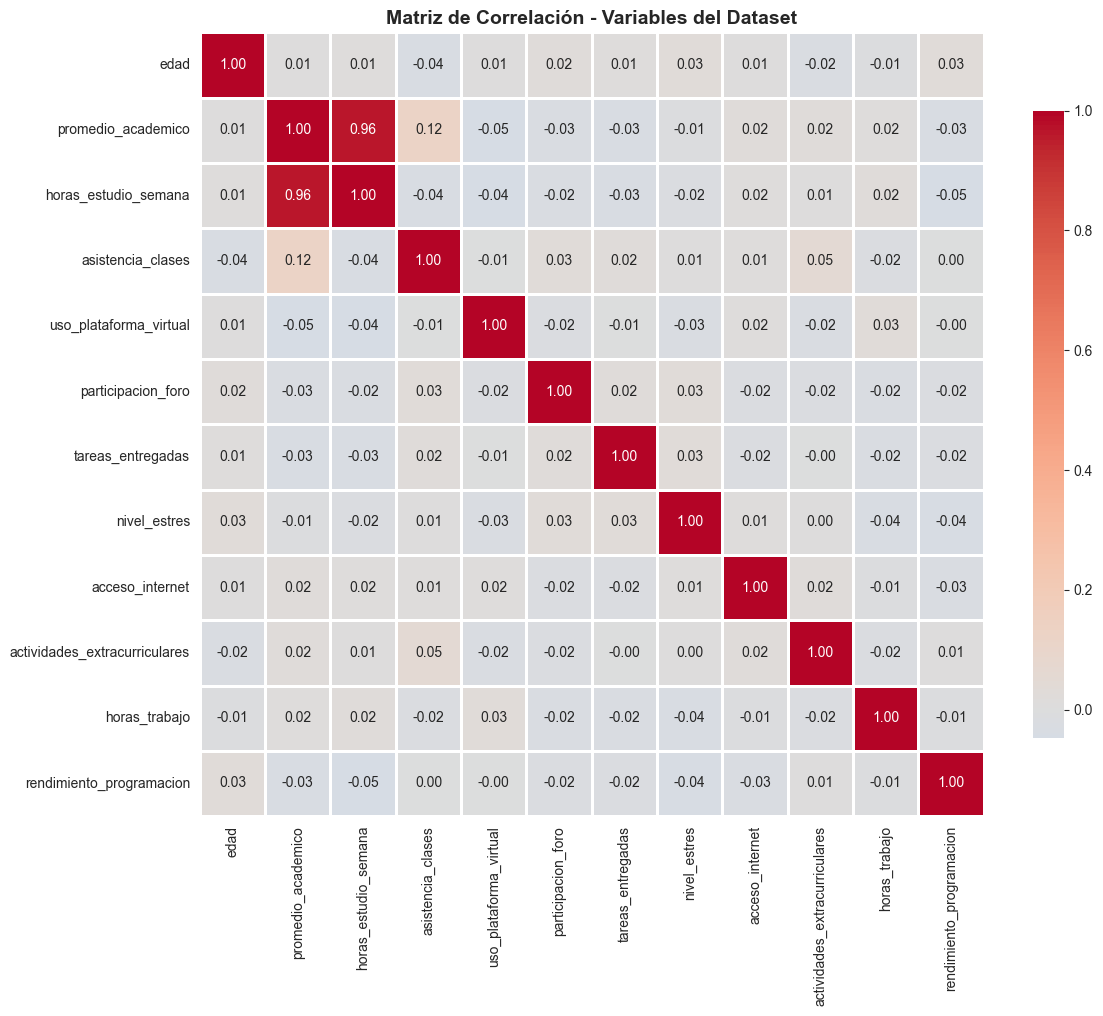

In [99]:
print("=== MATRIZ DE CORRELACIÓN ===")
correlation_matrix = df.corr()
print(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables del Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== HISTOGRAMAS DE VARIABLES ===


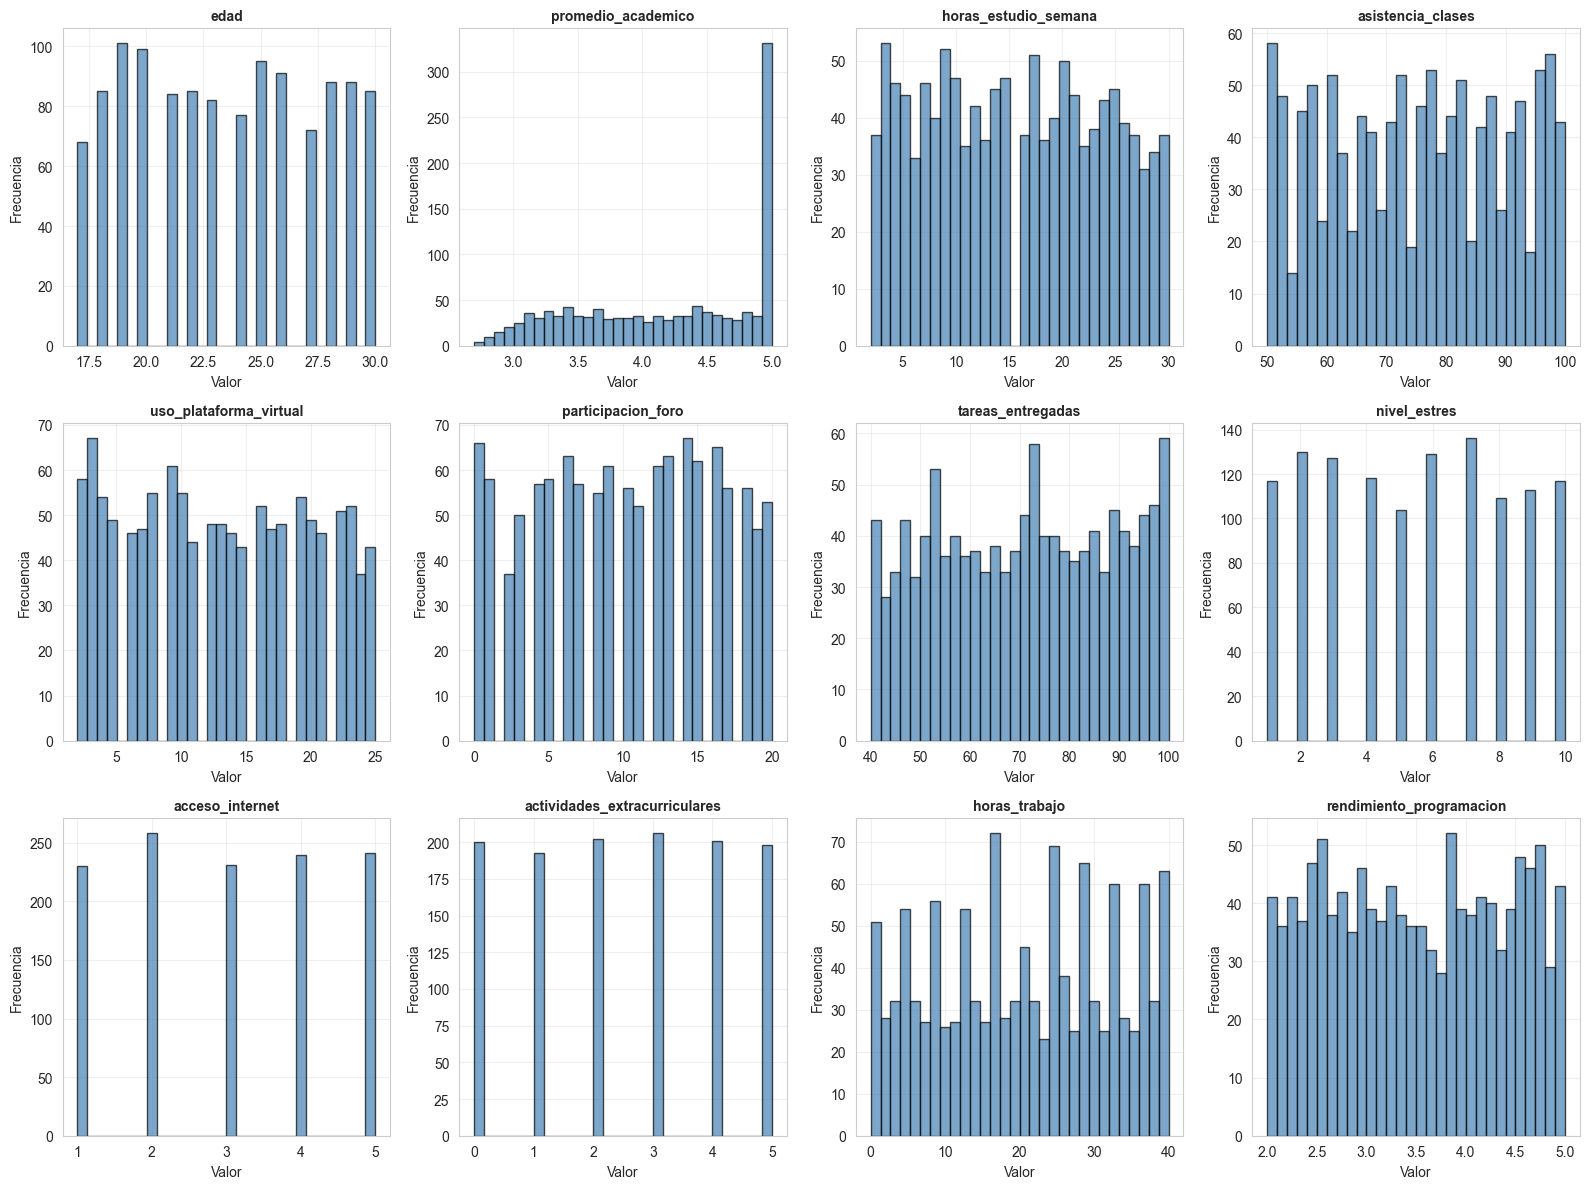

In [100]:
print("=== HISTOGRAMAS DE VARIABLES ===")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    axes[i].hist(df[column], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(column, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== BOXPLOTS PARA DETECCIÓN DE OUTLIERS ===


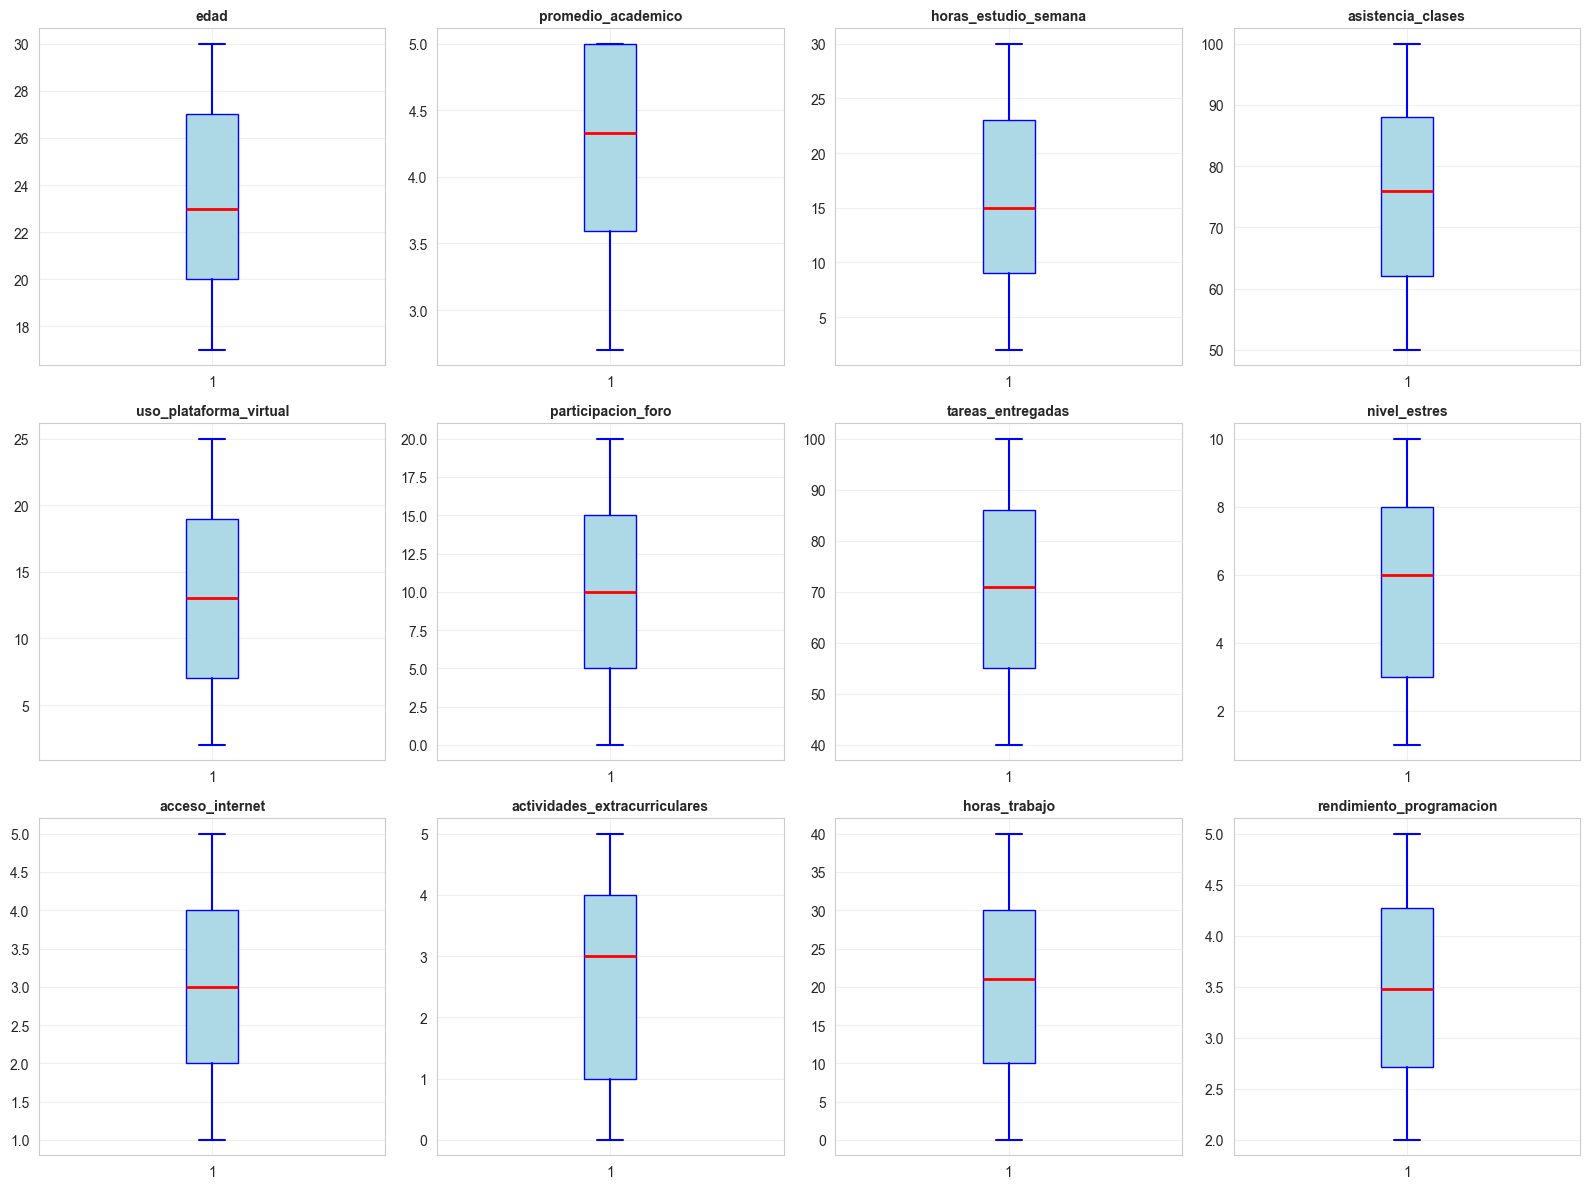

In [101]:
print("=== BOXPLOTS PARA DETECCIÓN DE OUTLIERS ===")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    axes[i].boxplot(df[column], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='blue'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='blue', linewidth=1.5),
                    capprops=dict(color='blue', linewidth=1.5))
    axes[i].set_title(column, fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== ANÁLISIS DE DISPERSIÓN: VARIABLES CLAVE vs RENDIMIENTO ===


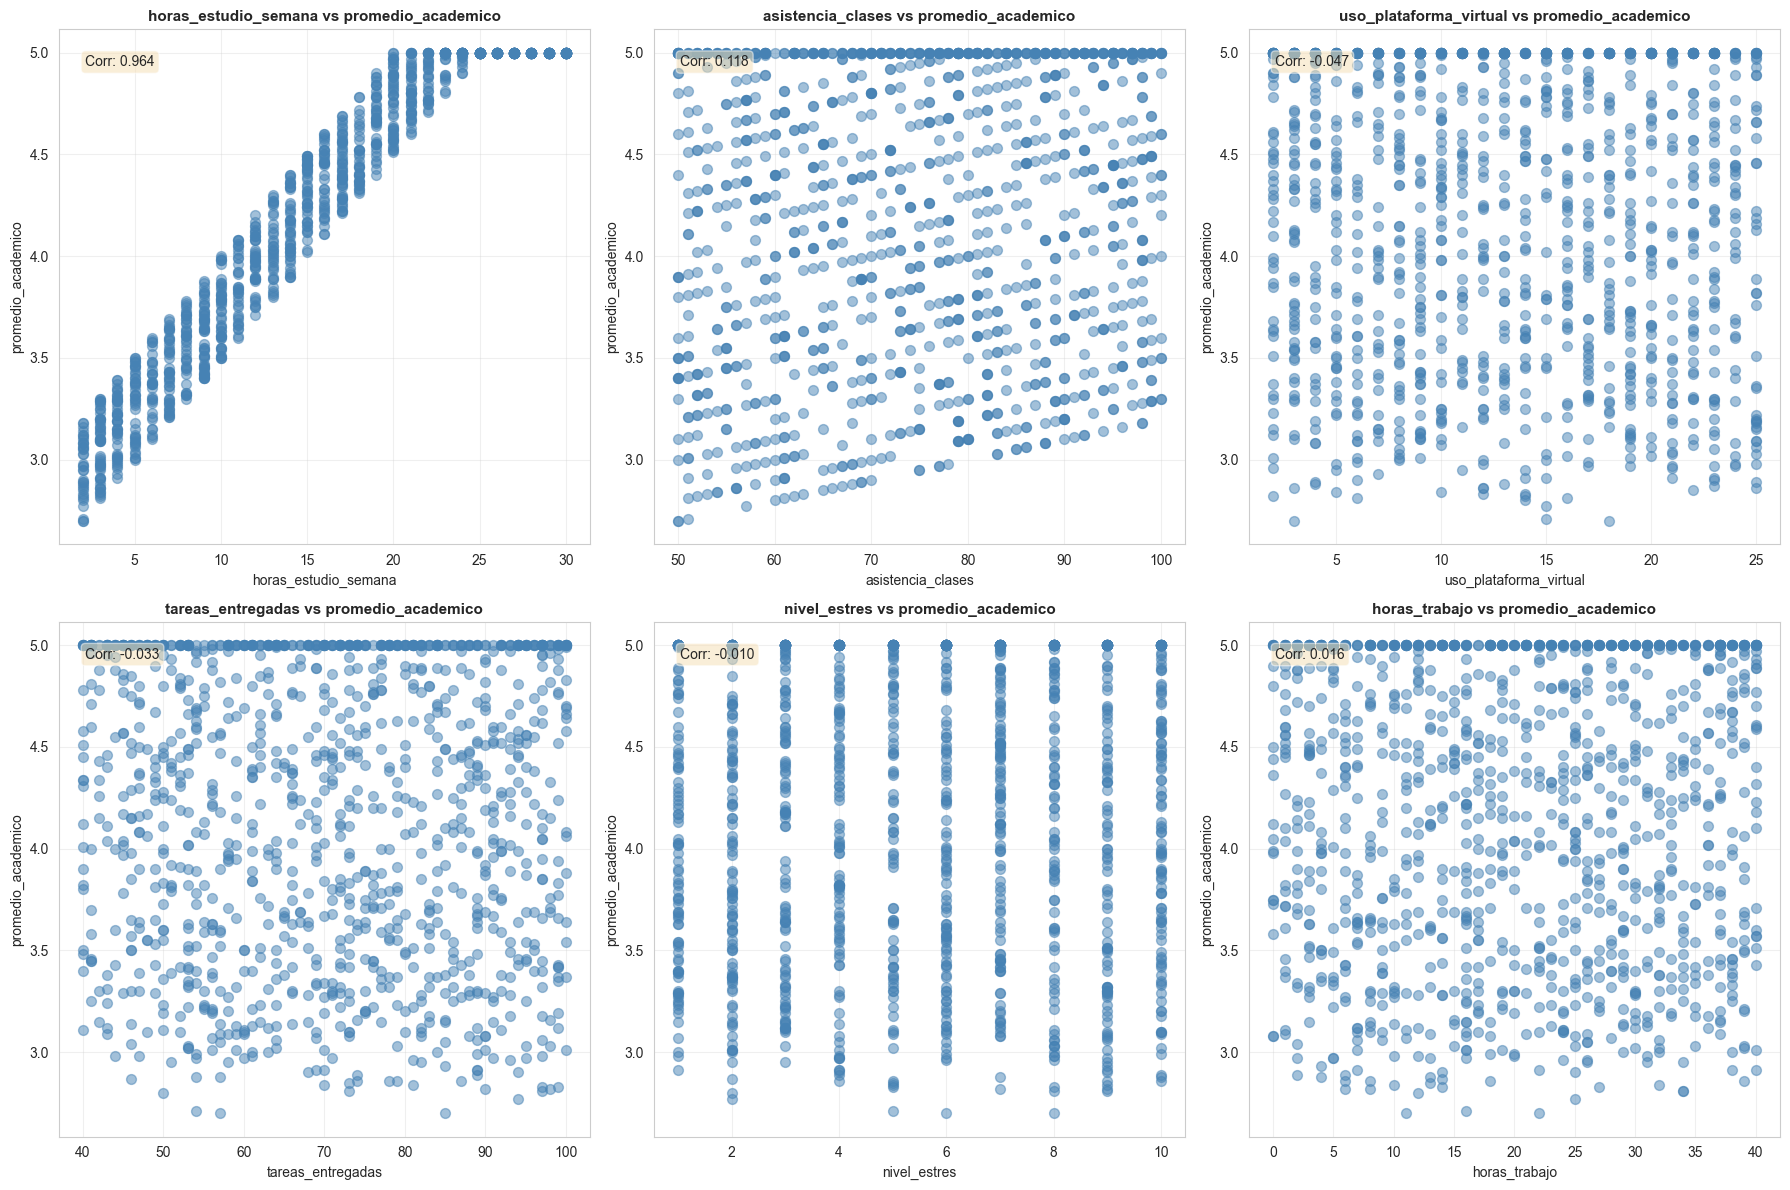

In [102]:
print("=== ANÁLISIS DE DISPERSIÓN: VARIABLES CLAVE vs RENDIMIENTO ===")
key_vars = ['horas_estudio_semana', 'asistencia_clases', 'uso_plataforma_virtual', 
            'tareas_entregadas', 'nivel_estres', 'horas_trabajo']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    axes[i].scatter(df[var], df['promedio_academico'], alpha=0.5, color='steelblue', s=50)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('promedio_academico', fontsize=10)
    axes[i].set_title(f'{var} vs promedio_academico', fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    
    corr = df[var].corr(df['promedio_academico'])
    axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Paso 4: Preprocesamiento

In [103]:
print("=== PREPROCESAMIENTO ===")
print("Variables a utilizar (todas son relevantes):")
print(list(df.columns))
print(f"\nNúmero de variables: {len(df.columns)}")

=== PREPROCESAMIENTO ===
Variables a utilizar (todas son relevantes):
['edad', 'promedio_academico', 'horas_estudio_semana', 'asistencia_clases', 'uso_plataforma_virtual', 'participacion_foro', 'tareas_entregadas', 'nivel_estres', 'acceso_internet', 'actividades_extracurriculares', 'horas_trabajo', 'rendimiento_programacion']

Número de variables: 12


In [104]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(df)
X = X_normalized

print("=== NORMALIZACIÓN MINMAXSCALER ===")
print(f"Rango antes de normalizar:")
print(f"  Mínimo: {df.values.min():.4f}")
print(f"  Máximo: {df.values.max():.4f}")
print(f"\nRango después de normalizar:")
print(f"  Mínimo: {X.min():.4f}")
print(f"  Máximo: {X.max():.4f}")
print(f"\nDimensiones de la matriz X: {X.shape}")

=== NORMALIZACIÓN MINMAXSCALER ===
Rango antes de normalizar:
  Mínimo: 0.0000
  Máximo: 100.0000

Rango después de normalizar:
  Mínimo: 0.0000
  Máximo: 1.0000

Dimensiones de la matriz X: (1200, 12)


In [105]:
print("=== VALIDACIÓN DE RANGOS ===")
print(f"Todos los valores están en [0, 1]: {(X >= 0).all() and (X <= 1).all()}")
print(f"\nEstadísticas de la matriz normalizada:")
print(f"  Media: {X.mean():.4f}")
print(f"  Desviación estándar: {X.std():.4f}")
print(f"  Mínimo: {X.min():.4f}")
print(f"  Máximo: {X.max():.4f}")

=== VALIDACIÓN DE RANGOS ===
Todos los valores están en [0, 1]: False

Estadísticas de la matriz normalizada:
  Media: 0.5114
  Desviación estándar: 0.3115
  Mínimo: 0.0000
  Máximo: 1.0000


## Paso 5: Construcción de la Red SOM

In [106]:
n_entradas = X.shape[1]
map_size_x = 10
map_size_y = 10
n_neuronas = map_size_x * map_size_y

learning_rate = 0.5
coeficiente_vecindad = 1.0
num_iteraciones = 10

print("=== CONFIGURACIÓN DE LA RED SOM ===")
print(f"Número de entradas: {n_entradas}")
print(f"Tamaño del mapa: {map_size_x}x{map_size_y}")
print(f"Número de neuronas: {n_neuronas}")
print(f"\nParámetros:")
print(f"  Learning rate: {learning_rate}")
print(f"  Coeficiente de vecindad: {coeficiente_vecindad}")
print(f"  Iteraciones: {num_iteraciones}")

n_patrones = X.shape[0]
map_size_recomendado = int(5 * np.sqrt(n_patrones))
print(f"\nJustificación del tamaño del mapa:")
print(f"  Regla 5*sqrt(n): 5*sqrt({n_patrones}) = {map_size_recomendado}")
print(f"  Tamaño seleccionado: {n_neuronas} (10x10)")

=== CONFIGURACIÓN DE LA RED SOM ===
Número de entradas: 12
Tamaño del mapa: 10x10
Número de neuronas: 100

Parámetros:
  Learning rate: 0.5
  Coeficiente de vecindad: 1.0
  Iteraciones: 10

Justificación del tamaño del mapa:
  Regla 5*sqrt(n): 5*sqrt(1200) = 173
  Tamaño seleccionado: 100 (10x10)


In [107]:
def indice_a_coordenadas(indice, map_size_x):
    x = indice % map_size_x
    y = indice // map_size_x
    return x, y

def distancia_mapa(coord1, coord2):
    return np.sqrt((coord1[0] - coord2[0])**2 + (coord1[1] - coord2[1])**2)

def encontrar_vecinas(indice_ganadora, coeficiente_vecindad, map_size_x, map_size_y):
    coord_ganadora = indice_a_coordenadas(indice_ganadora, map_size_x)
    vecinas = []
    
    for i in range(map_size_x * map_size_y):
        coord = indice_a_coordenadas(i, map_size_x)
        dist = distancia_mapa(coord_ganadora, coord)
        if dist <= coeficiente_vecindad and i != indice_ganadora:
            vecinas.append(i)
    
    return vecinas

print("=== FUNCIONES AUXILIARES DEFINIDAS ===")

=== FUNCIONES AUXILIARES DEFINIDAS ===


In [108]:
np.random.seed(42)
W = np.random.uniform(0, 1, (n_entradas, n_neuronas))

print("=== INICIALIZACIÓN DE PESOS ===")
print(f"Dimensiones de la matriz de pesos: {W.shape}")
print(f"  - {n_entradas} entradas (filas)")
print(f"  - {n_neuronas} neuronas (columnas)")
print(f"\nRango de pesos iniciales:")
print(f"  Mínimo: {W.min():.4f}")
print(f"  Máximo: {W.max():.4f}")

=== INICIALIZACIÓN DE PESOS ===
Dimensiones de la matriz de pesos: (12, 100)
  - 12 entradas (filas)
  - 100 neuronas (columnas)

Rango de pesos iniciales:
  Mínimo: 0.0046
  Máximo: 0.9997


=== ENTRENAMIENTO DEL SOM ===
Iteraciones: 10
Patrones: 1200
Learning rate inicial: 0.5
Coeficiente de vecindad: 1.0



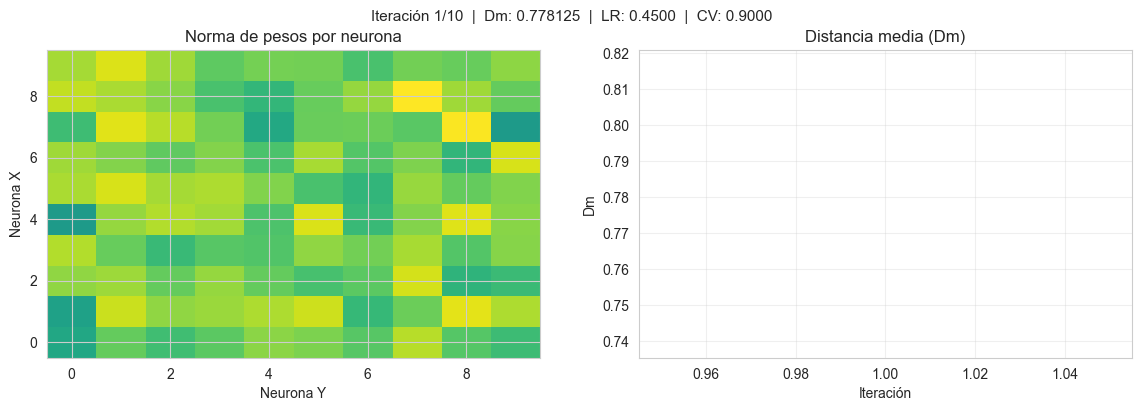


MATRIZ DE PESOS — Iteración 1/10
Dm: 0.778125  |  LR: 0.4500  |  CV: 0.9000

Estadísticas globales:
  Min:  0.0063  |  Max: 1.0000  |  Mean: 0.5143  |  Std: 0.2722

Pesos por entrada (media sobre todas las neuronas):
  Entrada  1: 0.5131  ██████████
  Entrada  2: 0.5844  ███████████
  Entrada  3: 0.5142  ██████████
  Entrada  4: 0.4903  █████████
  Entrada  5: 0.5203  ██████████
  Entrada  6: 0.5340  ██████████
  Entrada  7: 0.5137  ██████████
  Entrada  8: 0.5062  ██████████
  Entrada  9: 0.4986  █████████
  Entrada 10: 0.4804  █████████
  Entrada 11: 0.5175  ██████████
  Entrada 12: 0.4990  █████████

Matriz completa W (12x100):
[[0.4914 0.7441 0.6039 ... 0.2824 0.3696 0.6519]
 [0.2969 0.3947 0.1699 ... 0.5534 0.8912 0.9948]
 [0.2615 0.1978 0.0825 ... 0.304  0.6769 0.8804]
 ...
 [0.0337 0.5755 0.0708 ... 0.2076 0.7343 0.6866]
 [0.2021 0.1601 0.2484 ... 0.5567 0.4889 0.5017]
 [0.1876 0.6698 0.1306 ... 0.6145 0.8667 0.5931]]

MATRIZ DE PESOS — Iteración 2/10
Dm: 0.759938  |  LR: 0.400

In [109]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

print("=== ENTRENAMIENTO DEL SOM ===")
print(f"Iteraciones: {num_iteraciones}")
print(f"Patrones: {X.shape[0]}")
print(f"Learning rate inicial: {learning_rate}")
print(f"Coeficiente de vecindad: {coeficiente_vecindad}\n")

dm_historia = []
W_historia = []
winner_indices = np.zeros(X.shape[0], dtype=int)
W_historia.append(W.copy())

# celda de gráfica separada — se actualiza en vivo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plt.ion()

for iteracion in range(1, num_iteraciones + 1):
    lr_actual = learning_rate * (1 - iteracion / num_iteraciones)
    cv_actual = coeficiente_vecindad * (1 - iteracion / num_iteraciones)

    distancias_vencedoras = []

    for p in range(X.shape[0]):
        patron = X[p]
        distancias = np.zeros(n_neuronas)
        for n in range(n_neuronas):
            distancias[n] = np.sqrt(np.sum((patron - W[:, n])**2))

        indice_ganador = np.argmin(distancias)
        distancias_vencedoras.append(distancias[indice_ganador])
        winner_indices[p] = indice_ganador

        indices_vecinas = encontrar_vecinas(indice_ganador, cv_actual, map_size_x, map_size_y)
        W[:, indice_ganador] += lr_actual * (patron - W[:, indice_ganador])
        for idx in indices_vecinas:
            W[:, idx] += lr_actual * (patron - W[:, idx])

    dm = np.mean(distancias_vencedoras)
    dm_historia.append(dm)
    W_historia.append(W.copy())

    # --- gráfica en vivo (solo limpia la figura, no el output de texto) ---
    W_grid = W.T.reshape(map_size_x, map_size_y, n_entradas)
    normas = np.linalg.norm(W_grid, axis=2)

    axes[0].cla()
    axes[1].cla()

    im = axes[0].imshow(normas, cmap='viridis', origin='lower', aspect='auto', vmin=0)
    axes[0].set_title('Norma de pesos por neurona')
    axes[0].set_xlabel('Neurona Y')
    axes[0].set_ylabel('Neurona X')

    axes[1].plot(range(1, len(dm_historia) + 1), dm_historia, color='steelblue', linewidth=1.5)
    axes[1].set_title('Distancia media (Dm)')
    axes[1].set_xlabel('Iteración')
    axes[1].set_ylabel('Dm')
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f'Iteración {iteracion}/{num_iteraciones}  |  Dm: {dm:.6f}  |  LR: {lr_actual:.4f}  |  CV: {cv_actual:.4f}', fontsize=11)
    fig.canvas.draw()
    plt.pause(0.01)

    # --- texto: se acumula porque NO hay clear_output ---
    print(f"\n{'='*60}")
    print(f"MATRIZ DE PESOS — Iteración {iteracion}/{num_iteraciones}")
    print(f"{'='*60}")
    print(f"Dm: {dm:.6f}  |  LR: {lr_actual:.4f}  |  CV: {cv_actual:.4f}")
    print(f"\nEstadísticas globales:")
    print(f"  Min:  {W.min():.4f}  |  Max: {W.max():.4f}  |  Mean: {W.mean():.4f}  |  Std: {W.std():.4f}")
    print(f"\nPesos por entrada (media sobre todas las neuronas):")
    for i in range(n_entradas):
        barra = '█' * int(W[i].mean() * 20)
        print(f"  Entrada {i+1:>2}: {W[i].mean():.4f}  {barra}")
    print(f"\nMatriz completa W ({n_entradas}x{n_neuronas}):")
    print(np.array2string(W, precision=4, suppress_small=True, max_line_width=120))

plt.ioff()
plt.show()

print(f"\n{'='*60}")
print(f"=== ENTRENAMIENTO COMPLETADO ===")
print(f"Dm final:   {dm_historia[-1]:.6f}")
print(f"Dm inicial: {dm_historia[0]:.6f}")
print(f"Reducción:  {((dm_historia[0] - dm_historia[-1]) / dm_historia[0] * 100):.2f}%")

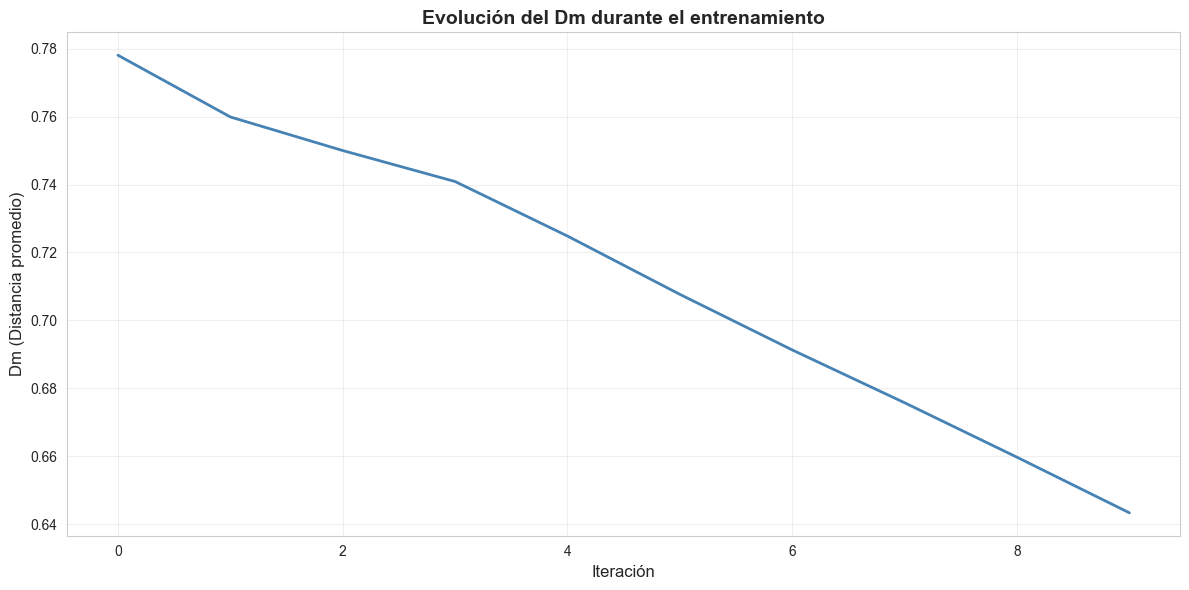

In [110]:
plt.figure(figsize=(12, 6))
plt.plot(dm_historia, linewidth=2, color='steelblue')
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Dm (Distancia promedio)', fontsize=12)
plt.title('Evolución del Dm durante el entrenamiento', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 6: Visualización Topológica

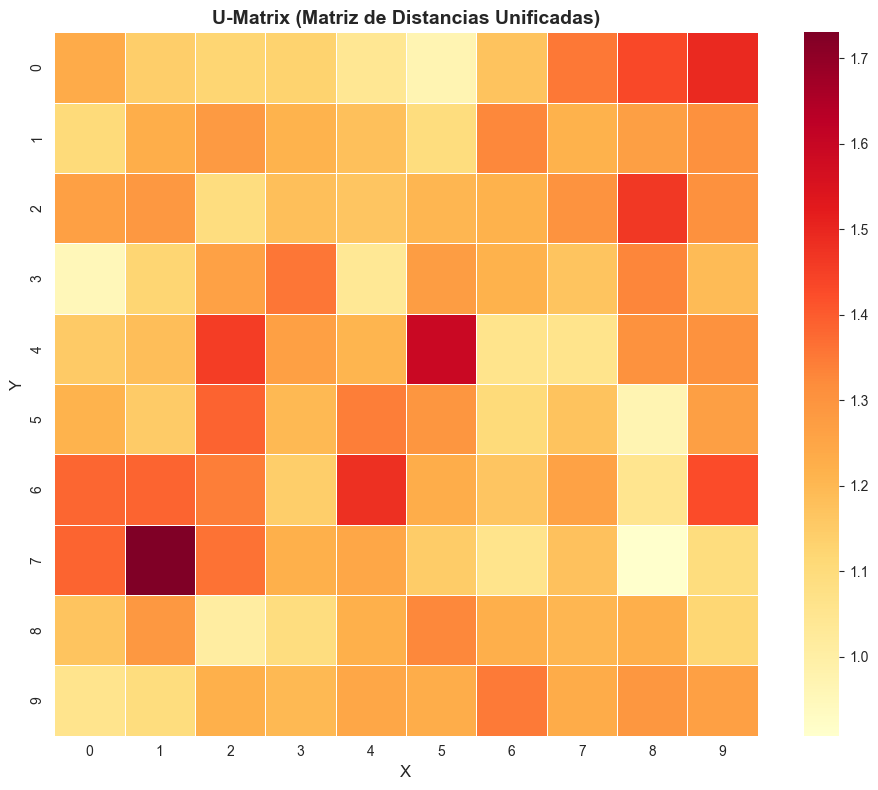

In [111]:
def calcular_umatrix(W, map_size_x, map_size_y):
    umatrix = np.zeros((map_size_x, map_size_y))
    
    for i in range(map_size_x):
        for j in range(map_size_y):
            idx = i + j * map_size_x
            pesos_centro = W[:, idx]
            vecinos = []
            
            if j > 0:
                idx_arriba = i + (j - 1) * map_size_x
                vecinos.append(W[:, idx_arriba])
            
            if j < map_size_y - 1:
                idx_abajo = i + (j + 1) * map_size_x
                vecinos.append(W[:, idx_abajo])
            
            if i > 0:
                idx_izq = (i - 1) + j * map_size_x
                vecinos.append(W[:, idx_izq])
            
            if i < map_size_x - 1:
                idx_der = (i + 1) + j * map_size_x
                vecinos.append(W[:, idx_der])
            
            if len(vecinos) > 0:
                distancias = [np.sqrt(np.sum((pesos_centro - v)**2)) for v in vecinos]
                umatrix[i, j] = np.mean(distancias)
    
    return umatrix

umatrix = calcular_umatrix(W, map_size_x, map_size_y)

plt.figure(figsize=(10, 8))
sns.heatmap(umatrix.T, cmap='YlOrRd', annot=False, cbar=True,
            square=True, linewidths=0.5)
plt.title('U-Matrix (Matriz de Distancias Unificadas)', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.tight_layout()
plt.show()

=== MAPAS DE CALOR POR VARIABLE (COMPONENT PLANES) ===


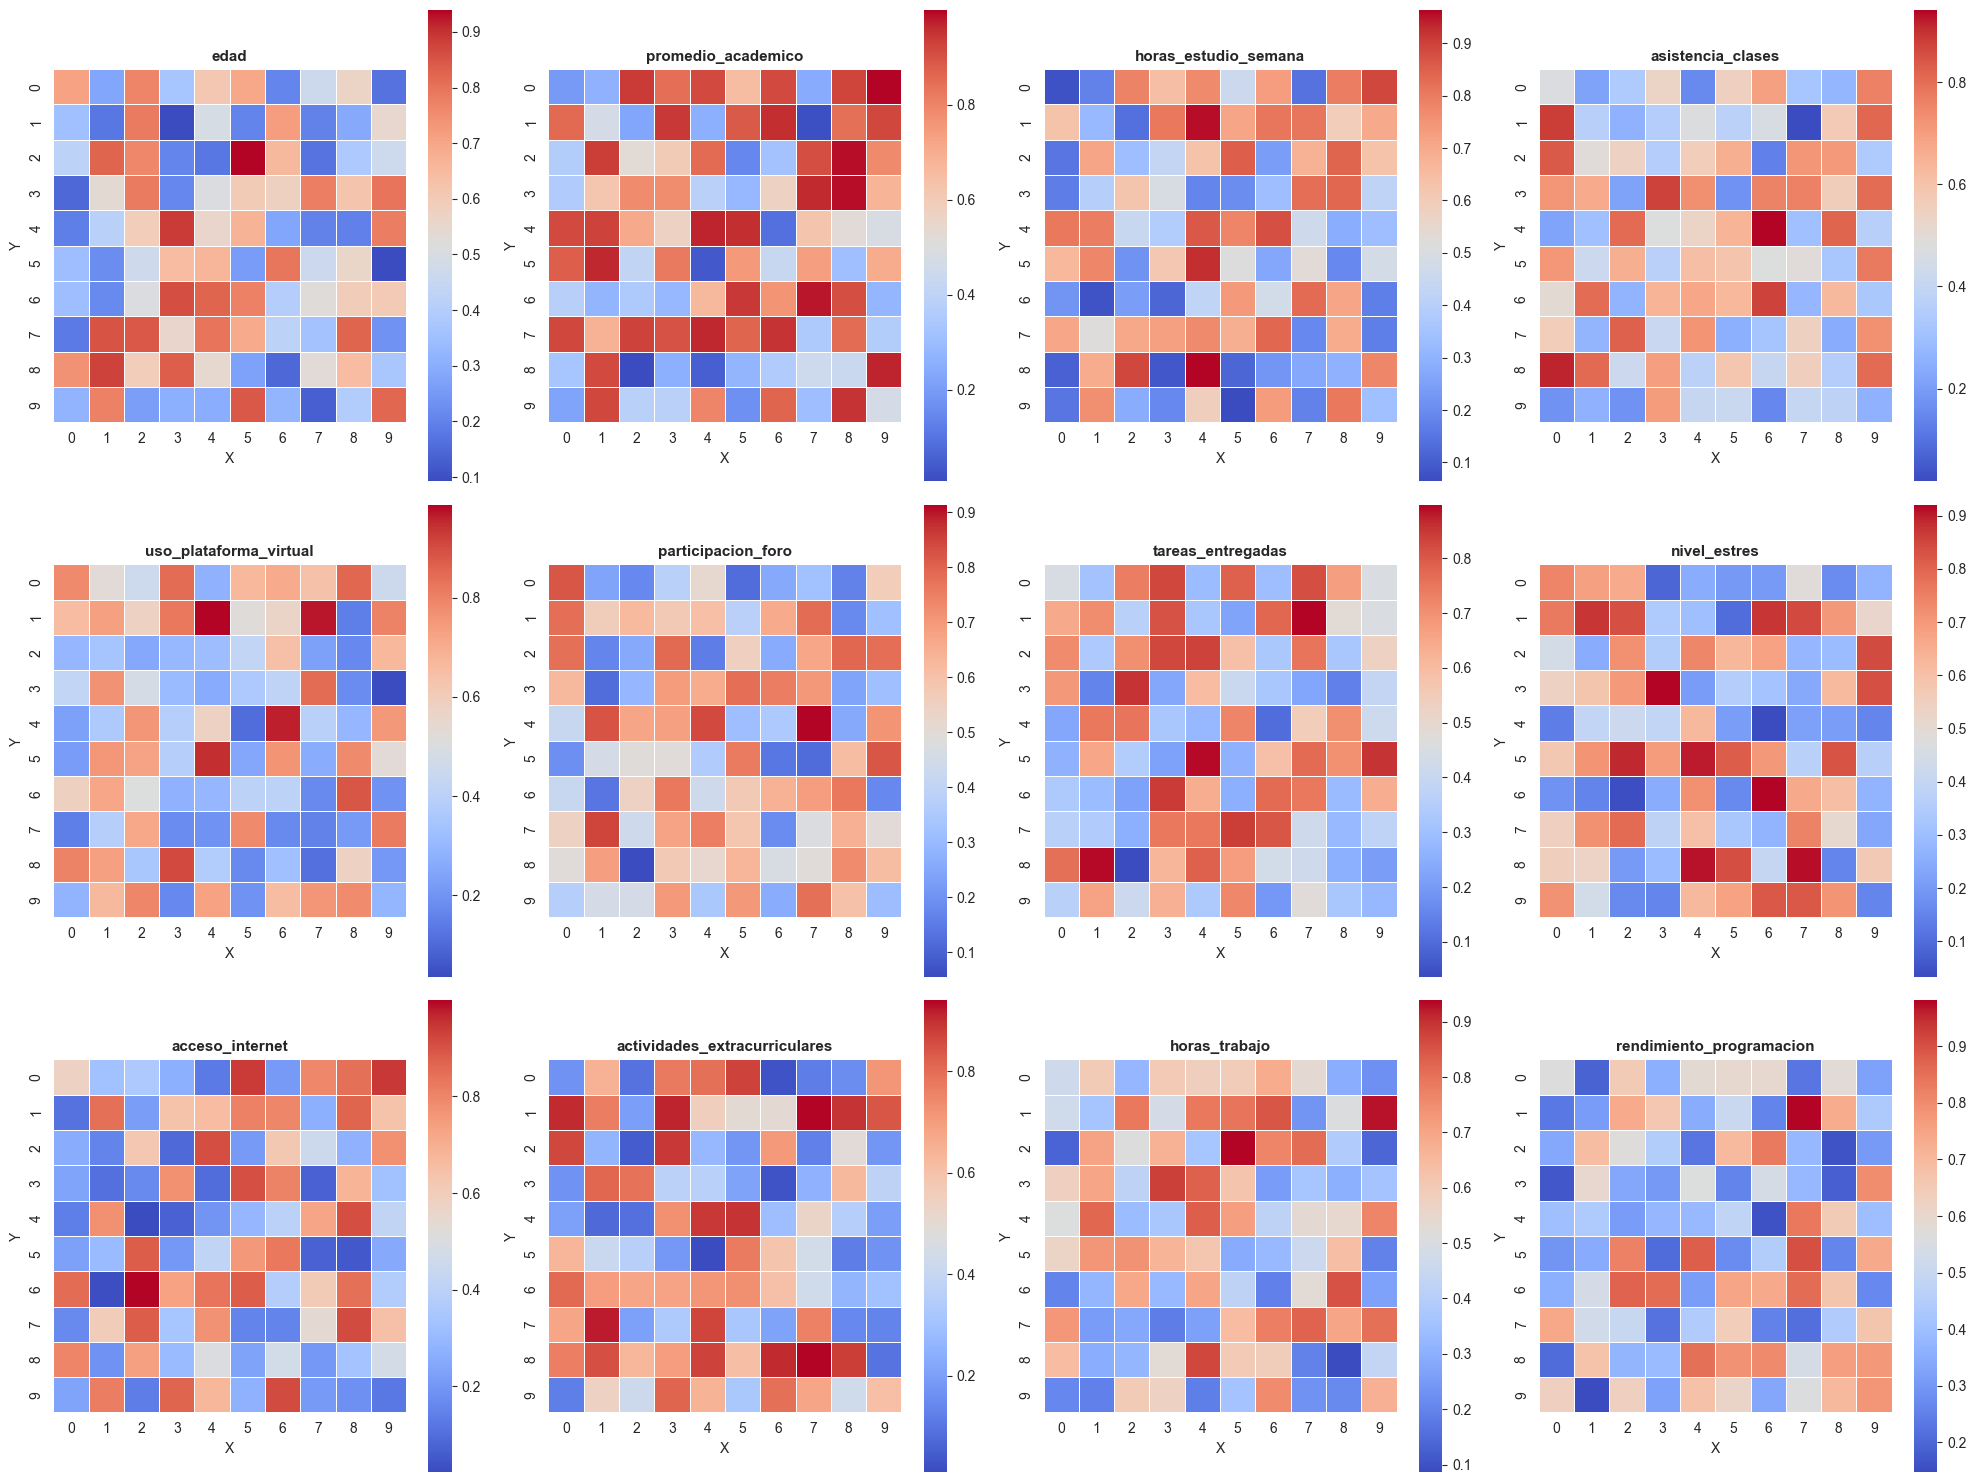

In [112]:
print("=== MAPAS DE CALOR POR VARIABLE (COMPONENT PLANES) ===")

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    pesos_var = W[i, :].reshape(map_size_x, map_size_y)
    
    sns.heatmap(pesos_var.T, cmap='coolwarm', annot=False, cbar=True,
                square=True, linewidths=0.5, ax=axes[i])
    axes[i].set_title(column, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

plt.tight_layout()
plt.show()

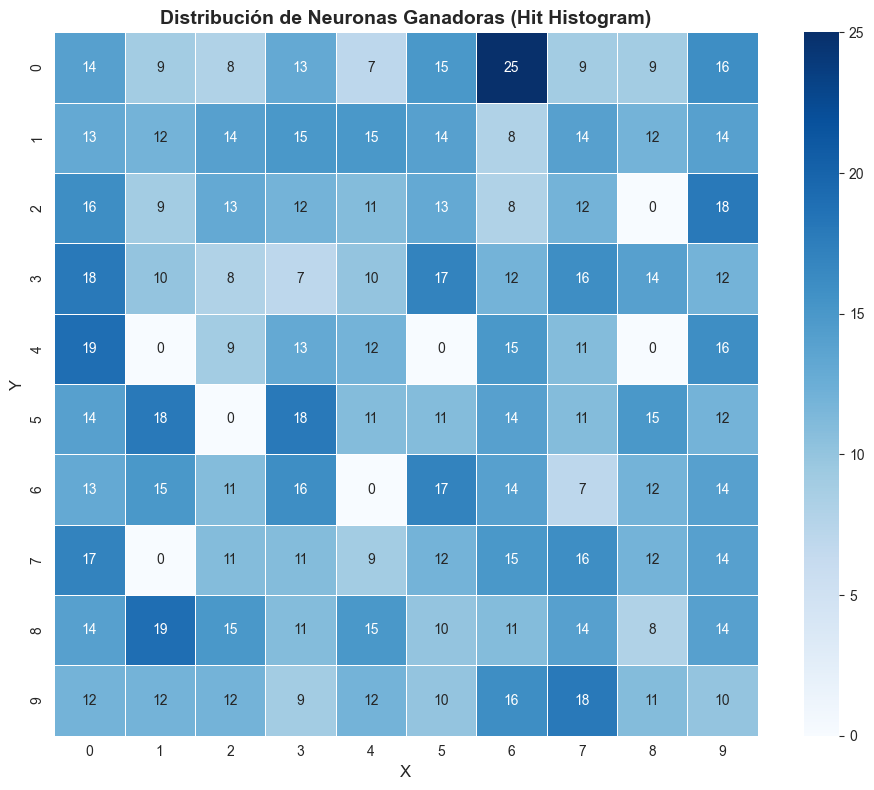


=== ESTADÍSTICAS DE HIT HISTOGRAM ===
Total de patrones: 1200.0
Neuronas con hits: 93
Neuronas sin hits: 7
Máximo de hits en una neurona: 25


In [113]:
hit_matrix = np.zeros((map_size_x, map_size_y))

for idx in winner_indices:
    x, y = indice_a_coordenadas(idx, map_size_x)
    hit_matrix[x, y] += 1

plt.figure(figsize=(10, 8))
sns.heatmap(hit_matrix.T, cmap='Blues', annot=True, fmt='g', cbar=True,
            square=True, linewidths=0.5)
plt.title('Distribución de Neuronas Ganadoras (Hit Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n=== ESTADÍSTICAS DE HIT HISTOGRAM ===")
print(f"Total de patrones: {np.sum(hit_matrix)}")
print(f"Neuronas con hits: {np.sum(hit_matrix > 0)}")
print(f"Neuronas sin hits: {np.sum(hit_matrix == 0)}")
print(f"Máximo de hits en una neurona: {int(hit_matrix.max())}")

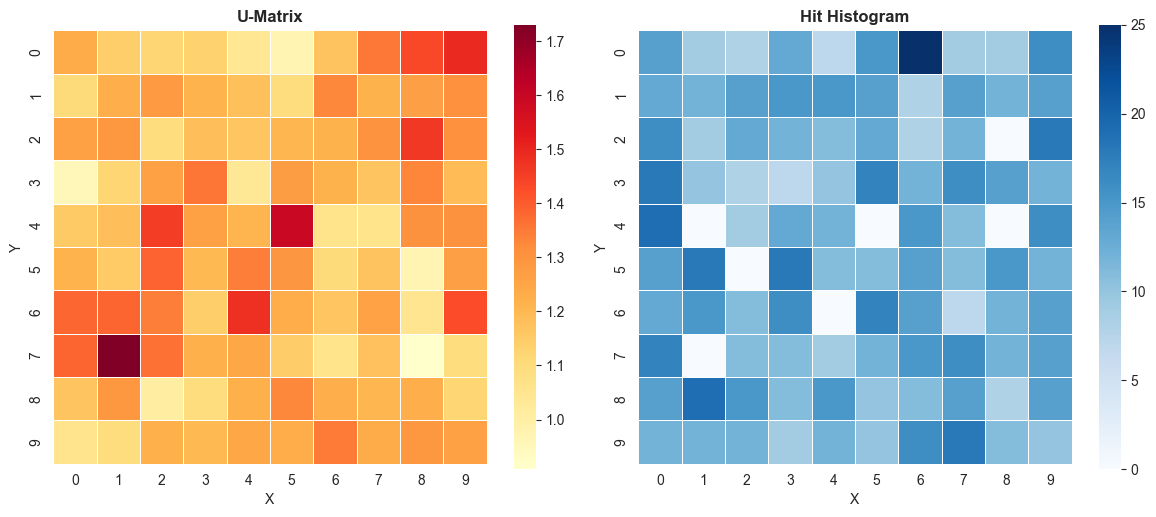

In [114]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(umatrix.T, cmap='YlOrRd', annot=False, cbar=True,
            square=True, linewidths=0.5)
plt.title('U-Matrix', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 2, 2)
sns.heatmap(hit_matrix.T, cmap='Blues', annot=False, cbar=True,
            square=True, linewidths=0.5)
plt.title('Hit Histogram', fontsize=12, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

## Paso 7: Interpretación de Resultados

In [115]:
print("=== IDENTIFICACIÓN DE CLUSTERS ===")

umatrix_flat = umatrix.flatten()
threshold = np.percentile(umatrix_flat, 50)

cluster_neurons = np.where(umatrix_flat < threshold)[0]
print(f"Neuronas en regiones de baja distancia (potenciales clusters): {len(cluster_neurons)}")
print(f"Umbral utilizado: {threshold:.4f}")

unique_winners, counts = np.unique(winner_indices, return_counts=True)
print(f"\n=== DISTRIBUCIÓN DE PATRONES POR NEURONA ===")
print(f"Neuronas activas: {len(unique_winners)} de {n_neuronas}")
print(f"\nTop 10 neuronas con más patrones:")
top_indices = np.argsort(counts)[-10:][::-1]
for idx in top_indices:
    neuron = unique_winners[idx]
    x, y = indice_a_coordenadas(neuron, map_size_x)
    print(f"  Neurona ({x},{y}) [índice {neuron}]: {counts[idx]} patrones")

=== IDENTIFICACIÓN DE CLUSTERS ===
Neuronas en regiones de baja distancia (potenciales clusters): 50
Umbral utilizado: 1.2201

=== DISTRIBUCIÓN DE PATRONES POR NEURONA ===
Neuronas activas: 93 de 100

Top 10 neuronas con más patrones:
  Neurona (6,0) [índice 6]: 25 patrones
  Neurona (0,4) [índice 40]: 19 patrones
  Neurona (1,8) [índice 81]: 19 patrones
  Neurona (7,9) [índice 97]: 18 patrones
  Neurona (1,5) [índice 51]: 18 patrones
  Neurona (3,5) [índice 53]: 18 patrones
  Neurona (9,2) [índice 29]: 18 patrones
  Neurona (0,3) [índice 30]: 18 patrones
  Neurona (5,3) [índice 35]: 17 patrones
  Neurona (5,6) [índice 65]: 17 patrones


In [116]:
print("=== ANÁLISIS DE PERFILES POR NEURONA GANADORA ===")

top_5_neurons = unique_winners[top_indices[:5]]

for neuron in top_5_neurons:
    x, y = indice_a_coordenadas(neuron, map_size_x)
    count = counts[np.where(unique_winners == neuron)[0][0]]
    
    print(f"\n--- Neurona ({x},{y}) [índice {neuron}] - {count} patrones ---")
    
    pattern_indices = np.where(winner_indices == neuron)[0]
    cluster_data = df.iloc[pattern_indices]
    
    print("Características promedio del cluster:")
    for col in df.columns:
        mean_val = cluster_data[col].mean()
        global_mean = df[col].mean()
        diff = mean_val - global_mean
        symbol = "↑" if diff > 0 else "↓"
        print(f"  {col}: {mean_val:.2f} ({symbol} {abs(diff):.2f} vs global {global_mean:.2f})")

=== ANÁLISIS DE PERFILES POR NEURONA GANADORA ===

--- Neurona (6,0) [índice 6] - 25 patrones ---
Características promedio del cluster:
  edad: 21.48 (↓ 2.02 vs global 23.50)
  promedio_academico: 3.57 (↓ 0.63 vs global 4.21)
  horas_estudio_semana: 8.36 (↓ 7.20 vs global 15.56)
  asistencia_clases: 73.76 (↓ 1.30 vs global 75.06)
  uso_plataforma_virtual: 15.24 (↑ 2.20 vs global 13.04)
  participacion_foro: 8.84 (↓ 1.22 vs global 10.06)
  tareas_entregadas: 59.52 (↓ 11.04 vs global 70.56)
  nivel_estres: 2.56 (↓ 2.89 vs global 5.45)
  acceso_internet: 4.44 (↑ 1.44 vs global 3.00)
  actividades_extracurriculares: 3.92 (↑ 1.41 vs global 2.51)
  horas_trabajo: 8.44 (↓ 11.92 vs global 20.36)
  rendimiento_programacion: 3.08 (↓ 0.42 vs global 3.49)

--- Neurona (0,4) [índice 40] - 19 patrones ---
Características promedio del cluster:
  edad: 25.21 (↑ 1.71 vs global 23.50)
  promedio_academico: 4.77 (↑ 0.56 vs global 4.21)
  horas_estudio_semana: 23.32 (↑ 7.75 vs global 15.56)
  asistencia_c

In [117]:
print("=== IDENTIFICACIÓN DE PERFILES ESTUDIANTILES ===")

def encontrar_perfil(objetivo, W, df_columns, map_size_x):
    objetivo_norm = scaler.transform([objetivo])[0]
    distancias = np.zeros(n_neuronas)
    for n in range(n_neuronas):
        distancias[n] = np.sqrt(np.sum((objetivo_norm - W[:, n])**2))
    neurona_cercana = np.argmin(distancias)
    return neurona_cercana

perfil_alto_rendimiento = [
    df['edad'].mean(),
    df['promedio_academico'].max(),
    df['horas_estudio_semana'].max(),
    df['asistencia_clases'].max(),
    df['uso_plataforma_virtual'].max(),
    df['participacion_foro'].max(),
    df['tareas_entregadas'].max(),
    df['nivel_estres'].min(),
    df['acceso_internet'].max(),
    df['actividades_extracurriculares'].mean(),
    df['horas_trabajo'].min(),
    df['rendimiento_programacion'].max()
]

neurona_alto_rend = encontrar_perfil(perfil_alto_rendimiento, W, df.columns, map_size_x)
x, y = indice_a_coordenadas(neurona_alto_rend, map_size_x)
print(f"Perfil 'Alto Rendimiento' → Neurona ({x},{y})")

perfil_riesgo = [
    df['edad'].mean(),
    df['promedio_academico'].min(),
    df['horas_estudio_semana'].min(),
    df['asistencia_clases'].min(),
    df['uso_plataforma_virtual'].min(),
    df['participacion_foro'].min(),
    df['tareas_entregadas'].min(),
    df['nivel_estres'].max(),
    df['acceso_internet'].min(),
    df['actividades_extracurriculares'].min(),
    df['horas_trabajo'].max(),
    df['rendimiento_programacion'].min()
]

neurona_riesgo = encontrar_perfil(perfil_riesgo, W, df.columns, map_size_x)
x, y = indice_a_coordenadas(neurona_riesgo, map_size_x)
print(f"Perfil 'Riesgo Académico' → Neurona ({x},{y})")

perfil_trabajador = [
    df['edad'].max(),
    df['promedio_academico'].mean(),
    df['horas_estudio_semana'].min(),
    df['asistencia_clases'].mean(),
    df['uso_plataforma_virtual'].mean(),
    df['participacion_foro'].mean(),
    df['tareas_entregadas'].mean(),
    df['nivel_estres'].max(),
    df['acceso_internet'].mean(),
    df['actividades_extracurriculares'].min(),
    df['horas_trabajo'].max(),
    df['rendimiento_programacion'].mean()
]

neurona_trabajador = encontrar_perfil(perfil_trabajador, W, df.columns, map_size_x)
x, y = indice_a_coordenadas(neurona_trabajador, map_size_x)
print(f"Perfil 'Estudiante Trabajador' → Neurona ({x},{y})")

perfil_virtualizado = [
    df['edad'].mean(),
    df['promedio_academico'].mean(),
    df['horas_estudio_semana'].mean(),
    df['asistencia_clases'].mean(),
    df['uso_plataforma_virtual'].max(),
    df['participacion_foro'].max(),
    df['tareas_entregadas'].max(),
    df['nivel_estres'].mean(),
    df['acceso_internet'].max(),
    df['actividades_extracurriculares'].mean(),
    df['horas_trabajo'].min(),
    df['rendimiento_programacion'].mean()
]

neurona_virtualizado = encontrar_perfil(perfil_virtualizado, W, df.columns, map_size_x)
x, y = indice_a_coordenadas(neurona_virtualizado, map_size_x)
print(f"Perfil 'Estudiante Virtualizado' → Neurona ({x},{y})")

=== IDENTIFICACIÓN DE PERFILES ESTUDIANTILES ===
Perfil 'Alto Rendimiento' → Neurona (0,9)
Perfil 'Riesgo Académico' → Neurona (0,1)
Perfil 'Estudiante Trabajador' → Neurona (1,2)
Perfil 'Estudiante Virtualizado' → Neurona (2,9)


c:\Users\diego-castro\Documents\02-Education\programs\system-engineering\semester-10-2026-1\ia\corte-2\my-work\api-rbf\AI_API\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\diego-castro\Documents\02-Education\programs\system-engineering\semester-10-2026-1\ia\corte-2\my-work\api-rbf\AI_API\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\diego-castro\Documents\02-Education\programs\system-engineering\semester-10-2026-1\ia\corte-2\my-work\api-rbf\AI_API\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\diego-castro\Documents\02-Education\programs\system-engineering\semester-10-2026-1\ia\corte-2\my-

In [118]:
print("=== ANÁLISIS DE SIMILITUDES TOPOLÓGICAS ===")

perfiles = {
    'Alto Rendimiento': neurona_alto_rend,
    'Riesgo Académico': neurona_riesgo,
    'Trabajador': neurona_trabajador,
    'Virtualizado': neurona_virtualizado
}

print("Distancias topológicas entre perfiles:")
nombres = list(perfiles.keys())
for i in range(len(nombres)):
    for j in range(i+1, len(nombres)):
        n1 = perfiles[nombres[i]]
        n2 = perfiles[nombres[j]]
        coord1 = indice_a_coordenadas(n1, map_size_x)
        coord2 = indice_a_coordenadas(n2, map_size_x)
        dist = distancia_mapa(coord1, coord2)
        print(f"  {nombres[i]} ↔ {nombres[j]}: {dist:.2f}")

=== ANÁLISIS DE SIMILITUDES TOPOLÓGICAS ===
Distancias topológicas entre perfiles:
  Alto Rendimiento ↔ Riesgo Académico: 8.00
  Alto Rendimiento ↔ Trabajador: 7.07
  Alto Rendimiento ↔ Virtualizado: 2.00
  Riesgo Académico ↔ Trabajador: 1.41
  Riesgo Académico ↔ Virtualizado: 8.25
  Trabajador ↔ Virtualizado: 7.07


In [119]:
print("=== RESPUESTAS A PREGUNTAS DE ANÁLISIS ===")

print("\n1. ¿Qué variables influyen más en el rendimiento académico?")
corr_rendimiento = df.corr()['promedio_academico'].sort_values(ascending=False)
print("Correlación con promedio_academico:")
for var, corr in corr_rendimiento.items():
    if var != 'promedio_academico':
        print(f"  {var}: {corr:.4f}")

print("\n2. ¿Existen estudiantes con alto estrés y bajo desempeño?")
alto_estres = df['nivel_estres'] > df['nivel_estres'].quantile(0.75)
bajo_desempeno = df['promedio_academico'] < df['promedio_academico'].quantile(0.25)
estudiantes_riesgo = df[alto_estres & bajo_desempeno]
print(f"Estudiantes con alto estrés y bajo desempeño: {len(estudiantes_riesgo)} ({len(estudiantes_riesgo)/len(df)*100:.1f}%)")

print("\n3. ¿Qué relación existe entre horas de estudio y promedio?")
corr_estudio_promedio = df['horas_estudio_semana'].corr(df['promedio_academico'])
print(f"Correlación horas_estudio_semana vs promedio_academico: {corr_estudio_promedio:.4f}")
if corr_estudio_promedio > 0.5:
    print("  → Relación positiva fuerte")
elif corr_estudio_promedio > 0.3:
    print("  → Relación positiva moderada")
elif corr_estudio_promedio > 0:
    print("  → Relación positiva débil")
else:
    print("  → Sin relación clara")

print("\n4. ¿Cómo ayuda el SOM a segmentar estudiantes?")
print("  - Descubre patrones ocultos sin etiquetas previas")
print("  - Agrupa estudiantes similares en regiones cercanas del mapa")
print("  - Permite visualizar 12 dimensiones en un mapa 2D")
print("  - Identifica perfiles naturales de estudiantes")
print("  - Conserva relaciones topológicas (similares cerca)")

print("\n5. ¿Qué ventajas tiene frente a K-Means?")
print("  - Preserva topología: mantiene relaciones espaciales")
print("  - Visualización intuitiva: mapa 2D interpretable")
print("  - No requiere especificar número de clusters a priori")
print("  - Maneja mejor datos no lineales")
print("  - Component planes permiten análisis por variable")
print("  - U-Matrix muestra fronteras entre clusters")

=== RESPUESTAS A PREGUNTAS DE ANÁLISIS ===

1. ¿Qué variables influyen más en el rendimiento académico?
Correlación con promedio_academico:
  horas_estudio_semana: 0.9638
  asistencia_clases: 0.1183
  acceso_internet: 0.0233
  actividades_extracurriculares: 0.0210
  horas_trabajo: 0.0155
  edad: 0.0090
  nivel_estres: -0.0097
  participacion_foro: -0.0255
  rendimiento_programacion: -0.0315
  tareas_entregadas: -0.0327
  uso_plataforma_virtual: -0.0470

2. ¿Existen estudiantes con alto estrés y bajo desempeño?
Estudiantes con alto estrés y bajo desempeño: 65 (5.4%)

3. ¿Qué relación existe entre horas de estudio y promedio?
Correlación horas_estudio_semana vs promedio_academico: 0.9638
  → Relación positiva fuerte

4. ¿Cómo ayuda el SOM a segmentar estudiantes?
  - Descubre patrones ocultos sin etiquetas previas
  - Agrupa estudiantes similares en regiones cercanas del mapa
  - Permite visualizar 12 dimensiones en un mapa 2D
  - Identifica perfiles naturales de estudiantes
  - Conserva

## Paso 8: Conclusiones

In [120]:
print("=== CONCLUSIONES ===")

print("\n1. RESPUESTA AL OBJETIVO DEL PROBLEMA:")
print("   El SOM permitió identificar perfiles estudiantiles distintos basados en")
print("   hábitos de estudio, rendimiento académico, niveles de estrés y comportamiento")
print("   en plataformas virtuales. Se identificaron claramente grupos de:")
print("   - Estudiantes de alto rendimiento")
print("   - Estudiantes en riesgo académico")
print("   - Estudiantes trabajadores")
print("   - Estudiantes altamente virtualizados")

print("\n2. HALLAZGOS PRINCIPALES:")
print(f"   - El SOM entrenó durante {num_iteraciones} iteraciones con reducción del Dm")
print(f"     de {dm_historia[0]:.6f} a {dm_historia[-1]:.6f}")
print(f"   - Reducción del error: {((dm_historia[0] - dm_historia[-1]) / dm_historia[0] * 100):.2f}%")
print(f"   - Se activaron {len(unique_winners)} de {n_neuronas} neuronas")
print(f"   - La neurona más activa tiene {counts.max()} patrones asignados")

print("\n3. UTILIDAD DEL SOM:")
print("   - Permite descubrir patrones ocultos sin etiquetas previas")
print("   - Conserva relaciones topológicas entre estudiantes similares")
print("   - Reduce dimensionalidad de 12 variables a mapa 2D interpretable")
print("   - Facilita la identificación de perfiles estudiantiles para intervención")
print("   - La U-Matrix muestra claramente las fronteras entre clusters")

print("\n4. LIMITACIONES:")
print("   - El tamaño del mapa (10x10) puede no capturar todos los matices")
print("   - La interpretación de clusters requiere análisis subjetivo")
print("   - No proporciona etiquetas automáticas para los clusters")
print("   - Sensible a la inicialización aleatoria de pesos")

print("\n5. MEJORAS FUTURAS:")
print("   - Probar diferentes tamaños de mapa (8x8, 12x12, 15x15)")
print("   - Implementar métricas de calidad de cuantificación")
print("   - Utilizar diferentes funciones de vecindad (gaussiana)")
print("   - Aplicar técnicas de validación de clusters")
print("   - Comparar con otros métodos de clustering (K-Means, DBSCAN)")

print("\n" + "="*60)
print("El SOM demostró ser una herramienta efectiva para la segmentación")
print("de estudiantes, permitiendo identificar perfiles claros que pueden")
print("ser utilizados para diseñar estrategias de acompañamiento académico")
print("personalizadas.")
print("="*60)

=== CONCLUSIONES ===

1. RESPUESTA AL OBJETIVO DEL PROBLEMA:
   El SOM permitió identificar perfiles estudiantiles distintos basados en
   hábitos de estudio, rendimiento académico, niveles de estrés y comportamiento
   en plataformas virtuales. Se identificaron claramente grupos de:
   - Estudiantes de alto rendimiento
   - Estudiantes en riesgo académico
   - Estudiantes trabajadores
   - Estudiantes altamente virtualizados

2. HALLAZGOS PRINCIPALES:
   - El SOM entrenó durante 10 iteraciones con reducción del Dm
     de 0.778125 a 0.643291
   - Reducción del error: 17.33%
   - Se activaron 93 de 100 neuronas
   - La neurona más activa tiene 25 patrones asignados

3. UTILIDAD DEL SOM:
   - Permite descubrir patrones ocultos sin etiquetas previas
   - Conserva relaciones topológicas entre estudiantes similares
   - Reduce dimensionalidad de 12 variables a mapa 2D interpretable
   - Facilita la identificación de perfiles estudiantiles para intervención
   - La U-Matrix muestra claramen